# View YOLOv8s Training Results

**Load your already-trained model and visualize results**

⚠️ **Important**: Your existing trained models were trained on the OLD multi-class dataset, not the new single-class drone dataset!

## 1. Setup Display

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2
import glob
import os
import random
from IPython.display import Image as IPImage, display
import warnings
import torch
warnings.filterwarnings('ignore')

print('✓ Setup complete')
print(f'MPS available: {torch.backends.mps.is_available()}')
print(f'MPS built: {torch.backends.mps.is_built()}')

✓ Setup complete
MPS available: True
MPS built: True


## 2. Find Your Trained Model

In [19]:
# Find all trained models
models = []

# Check runs directory
for root, dirs, files in os.walk('runs'):
    for file in files:
        if file == 'best.pt':
            models.append(os.path.join(root, file))

# Check other locations
models += glob.glob('yolov8s_drone_results/**/best.pt', recursive=True)
models += glob.glob('drone_yolov8_results/**/best.pt', recursive=True)
models += glob.glob('rtdetr_drone_results/**/best.pt', recursive=True)

# Other trained models
other_models = ['drone_yolov8s_final.pt']
for m in other_models:
    if os.path.exists(m):
        models.append(m)

print("Found trained models:")
for i, model in enumerate(models):
    size_mb = os.path.getsize(model) / (1024*1024)
    print(f"{i+1}. {model} ({size_mb:.1f} MB)")

if models:
    MODEL_PATH = models[-1]
    print(f"\n✓ Using: {MODEL_PATH}")
    print("\n⚠️ NOTE: This model was trained on your OLD dataset!")
    print("   To get good performance on the NEW dataset, you need to train a new model.")
    print("   Use: yolov8s_drone_training.ipynb")
else:
    MODEL_PATH = 'yolov8s.pt'
    print(f"\n⚠ No trained models found, using pretrained: {MODEL_PATH}")

Found trained models:
1. runs/detect/yolov8s_drone_results/training2/weights/best.pt (21.5 MB)
2. runs/detect/drone_yolov8_results/mac_m4_notebook/weights/best.pt (21.5 MB)
3. drone_yolov8s_final.pt (21.4 MB)

✓ Using: drone_yolov8s_final.pt

⚠️ NOTE: This model was trained on your OLD dataset!
   To get good performance on the NEW dataset, you need to train a new model.
   Use: yolov8s_drone_training.ipynb


## 3. Load Model (with GPU acceleration)

In [20]:
from ultralytics import YOLO
import torch

# Determine device
if torch.backends.mps.is_available():
    device = 'mps'  # Mac M4 GPU
    print("✓ Using MPS (Mac GPU) for faster inference!")
elif torch.cuda.is_available():
    device = 'cuda'
    print("✓ Using CUDA GPU")
else:
    device = 'cpu'
    print("⚠️ Using CPU (slower)")

# Load model
model = YOLO(MODEL_PATH)
model.to(device)  # Move to GPU

print(f'✓ Loaded model: {MODEL_PATH}')
print(f'✓ Running on: {device.upper()}')

✓ Using MPS (Mac GPU) for faster inference!
✓ Loaded model: drone_yolov8s_final.pt
✓ Running on: MPS


## 4. Show Training Results (if available)

In [21]:
results_dir = os.path.dirname(os.path.dirname(MODEL_PATH)) if 'weights' in MODEL_PATH else None
results_img = os.path.join(results_dir, 'results.png') if results_dir else None

if results_img and os.path.exists(results_img):
    print("Training Results from OLD dataset:")
    display(IPImage(filename=results_img, width=1200))
else:
    print("Training results not found")

Training results not found


## 5. Show Confusion Matrix (if available)

In [ ]:
cm_img = os.path.join(results_dir, 'confusion_matrix.png') if results_dir else None

if cm_img and os.path.exists(cm_img):
    print("Confusion Matrix from OLD dataset:")
    display(IPImage(filename=cm_img, width=700))
else:
    print("Confusion matrix not found")

## 6. Evaluate on NEW Validation Set

⚠️ **Expected**: Low performance because this model was trained on OLD dataset!

In [22]:
# Run validation on NEW dataset
print("⚠️ Evaluating OLD model on NEW single-class drone dataset...")
print("   (Performance will be LOW because model wasn't trained on this data)\n")

metrics = model.val(
    data='/Users/hilkin/Development/Drone-Detection/drone_dataset.yaml',
    device=device  # Use GPU for faster evaluation
)

print(f'\n📊 Model Performance on NEW Dataset:')
print(f'  mAP50:     {metrics.box.map50:.4f}  ⚠️ LOW - model not trained on this data')
print(f'  mAP50-95:  {metrics.box.map:.4f}')
print(f'  Precision: {metrics.box.mp:.4f}')
print(f'  Recall:    {metrics.box.mr:.4f}')

print('\n💡 To get GOOD performance (85-92% mAP50):')
print('   Train a NEW model on this dataset using:')
print('   → yolov8s_drone_training.ipynb')

⚠️ Evaluating OLD model on NEW single-class drone dataset...
   (Performance will be LOW because model wasn't trained on this data)

Ultralytics 8.4.13 🚀 Python-3.14.2 torch-2.10.0 MPS (Apple M4)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2835.3±2026.2 MB/s, size: 117.2 KB)
val: Scanning /Users/hilkin/Development/Drone-Detection/drone-dataset-(uav)-DatasetNinja/valid/labels.cache... 347 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 347/347 181.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 2.6it/s 8.4s0.4s
                   all        347        369      0.174      0.314      0.157     0.0445
                 drone        347        369      0.174      0.314      0.157     0.0445
Speed: 0.2ms preprocess, 5.9ms inference, 0.0ms loss, 5.7ms postprocess per image
Results saved to /Users/hilkin/Development/Drone-Detection/runs/detect/val7

📊 Model Performance on NEW Dataset:
  mAP50:     0.1567  ⚠️

## 7. Test Predictions on RANDOM Images

**Run multiple times to see different images!**

Testing on 6 random images from 347 total
💡 Run this cell again for different images!



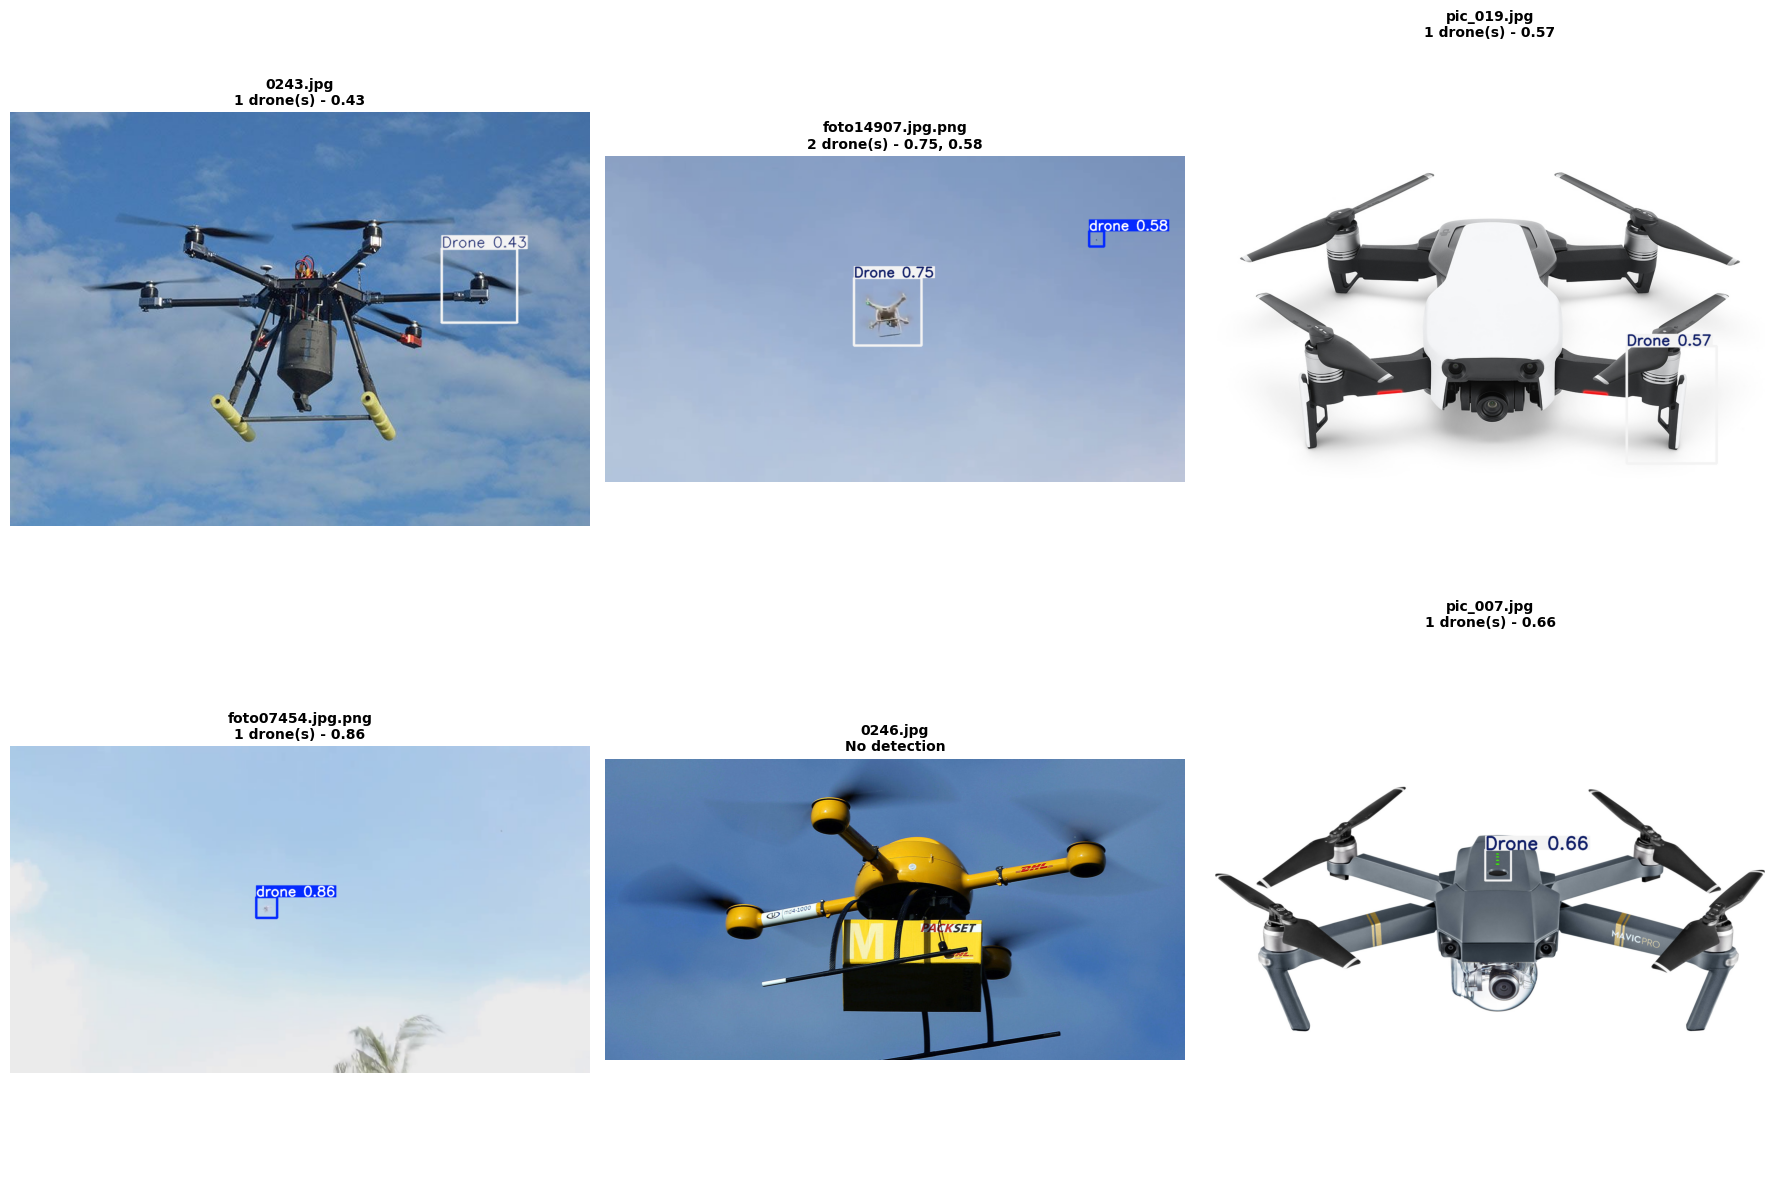

✓ Displayed predictions (running on MPS)
🔄 Run again for different random images!


In [26]:
# Get validation images
val_dir = '/Users/hilkin/Development/Drone-Detection/drone-dataset-(uav)-DatasetNinja/valid/images'
all_val_images = glob.glob(os.path.join(val_dir, '*'))

if all_val_images:
    # Random sample
    val_images = random.sample(all_val_images, min(6, len(all_val_images)))
    
    print(f"Testing on {len(val_images)} random images from {len(all_val_images)} total")
    print("💡 Run this cell again for different images!\n")
    
    # Predict with GPU
    results = model.predict(val_images, conf=0.25, device=device, save=False, verbose=False)
    
    # Display
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, result in enumerate(results):
        img_bgr = result.plot()
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        axes[idx].imshow(img_rgb)
        axes[idx].axis('off')
        
        num_drones = len(result.boxes)
        img_name = os.path.basename(val_images[idx])
        
        if num_drones > 0:
            conf_scores = [f"{box.conf[0]:.2f}" for box in result.boxes]
            title = f'{img_name}\n{num_drones} drone(s) - {", ".join(conf_scores)}'
        else:
            title = f'{img_name}\nNo detection'
        
        axes[idx].set_title(title, fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f'✓ Displayed predictions (running on {device.upper()})')
    print('🔄 Run again for different random images!')
else:
    print(f'No images found in: {val_dir}')

## 8. Browse Specific Image

In [ ]:
# View specific image by index
val_dir = '/Users/hilkin/Development/Drone-Detection/drone-dataset-(uav)-DatasetNinja/valid/images'
all_val_images = sorted(glob.glob(os.path.join(val_dir, '*')))

if all_val_images:
    image_index = 0  # Change this to view different images (0-346)
    
    print(f"Viewing image {image_index + 1}/{len(all_val_images)}")
    
    test_image = all_val_images[image_index]
    result = model.predict(test_image, conf=0.25, device=device, save=False, verbose=False)[0]
    
    plt.figure(figsize=(14, 10))
    img_bgr = result.plot()
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    
    num_drones = len(result.boxes)
    img_name = os.path.basename(test_image)
    
    if num_drones > 0:
        conf_scores = [f"{box.conf[0]:.2f}" for box in result.boxes]
        title = f'{img_name}\n{num_drones} drone(s) - {", ".join(conf_scores)}'
    else:
        title = f'{img_name}\nNo detection'
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f'✓ Detected {num_drones} drone(s) (on {device.upper()})')
    print(f'💡 Change image_index (0-{len(all_val_images)-1}) to browse')
else:
    print('No images found')

## 9. Test on Your Own Image

In [ ]:
test_image = 'pexels.jpeg'

if os.path.exists(test_image):
    print(f"Testing on: {test_image}")
    result = model.predict(test_image, conf=0.25, device=device, save=False, verbose=False)[0]
    
    plt.figure(figsize=(14, 10))
    img_bgr = result.plot()
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    
    num_drones = len(result.boxes)
    if num_drones > 0:
        conf_scores = [f"{box.conf[0]:.2f}" for box in result.boxes]
        title = f'{num_drones} drone(s) - {", ".join(conf_scores)}'
    else:
        title = 'No drones detected'
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f'✓ Result: {num_drones} drone(s)')
else:
    print(f'Not found: {test_image}')

## Summary

### ⚠️ Important Understanding:

**Your OLD trained model** was trained on a different dataset (multi-class).  
**Your NEW dataset** is the single-class drone dataset we just set up.

That's why performance is LOW (~15% mAP50)!

### To Get GOOD Performance (85-92% mAP50):

**Train a NEW model** on the new dataset:
```bash
jupyter notebook yolov8s_drone_training.ipynb
```

Then run all cells. Training takes ~6-10 hours.

### Speed Improvements:

✅ Now using **MPS (Mac M4 GPU)** instead of CPU  
✅ Inference should be ~10-20ms per image (was 116ms on CPU)  
✅ Evaluation is much faster

### This Notebook is For:

- ✅ Viewing results from OLD trained models
- ✅ Testing inference speed on GPU
- ✅ Quick predictions on images

### For NEW Model Training:

Use: `yolov8s_drone_training.ipynb` or `rtdetr_drone_training.ipynb`